In [1]:
# ===============================
# 1. IMPORTS
# ===============================
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ===============================
# 2. CHEMINS ET PARAMÈTRES
# ===============================
DATASET_PATH = r"C:\Users\Lenovo\Desktop\projects M1\plant-disease-ai\dataset"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

# ===============================
# 3. CHARGEMENT DES DATASETS
# ===============================
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# ===============================
# 4. NOMS DES CLASSES
# ===============================
class_names = train_dataset.class_names
print("Classes :", class_names)

# ===============================
# 5. OPTIMISATION DU PIPELINE
# ===============================
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

# ===============================
# 6. DATA AUGMENTATION (Sequential)
# ===============================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

# ===============================
# 7. MODÈLE AVEC FUNCTIONAL API
# ===============================
# Entrée
inputs = layers.Input(shape=(224, 224, 3))

# Augmentation
x = data_augmentation(inputs)

# Prétraitement spécifique EfficientNet
x = layers.Lambda(preprocess_input)(x)

# Base EfficientNetB0 (pré-entraîné, frozen)
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False
x = base_model(x)

# Tête de classification
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(6, activation='softmax')(x)

# Création du modèle
efficientnet_model = Model(inputs=inputs, outputs=outputs)

# ===============================
# 8. COMPILATION
# ===============================
efficientnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ===============================
# 9. RÉSUMÉ DU MODÈLE (optionnel)
# ===============================
efficientnet_model.summary()

# ===============================
# 10. (Optionnel) Callback EarlyStopping
# ===============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("✅ Modèle prêt pour l'entraînement. Exécutez ensuite :")
print("history = efficientnet_model.fit(train_dataset, validation_data=validation_dataset, epochs=10, callbacks=[early_stop])")

Found 6652 files belonging to 6 classes.
Using 5322 files for training.
Found 6652 files belonging to 6 classes.
Using 1330 files for validation.
Classes : ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_healthy']



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

✅ Modèle prêt pour l'entraînement. Exécutez ensuite :
history = efficientnet_model.fit(train_dataset, validation_data=validation_dataset, epochs=10, callbacks=[early_stop])


In [2]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
import tensorflow as tf

# Chemin Windows (adapté à ton environnement)
model_path = r"C:\Users\Lenovo\Desktop\projects M1\plant-disease-ai\models\efficientnet_model.h5"

# Charger avec l'objet custom_objects pour preprocess_input
model = load_model(model_path, custom_objects={'preprocess_input': preprocess_input})
print("✅ Modèle chargé")

✅ Modèle chargé


In [3]:
# Chemin de l'image test
img_path = r"C:\Users\Lenovo\Desktop\projects M1\plant-disease-ai\test_leaf.jpg"

# Charger et prétraiter
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Prédiction
predictions = model.predict(img_array)
pred_class = np.argmax(predictions[0])
confidence = np.max(predictions[0])

# Noms des classes (doivent correspondre à l'ordre utilisé lors de l'entraînement)
class_names = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
               'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_healthy']

print(f"Classe prédite : {class_names[pred_class]}")
print(f"Confiance : {confidence:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Classe prédite : Potato___Early_blight
Confiance : 0.6271


In [7]:
for layer in model.layers:
    print(layer.name)

sequential_2
lambda_1
efficientnetb0
global_average_pooling2d_1
dropout_3
dense_6
dense_7


✅ Carte de saillance générée, shape : (224, 224)


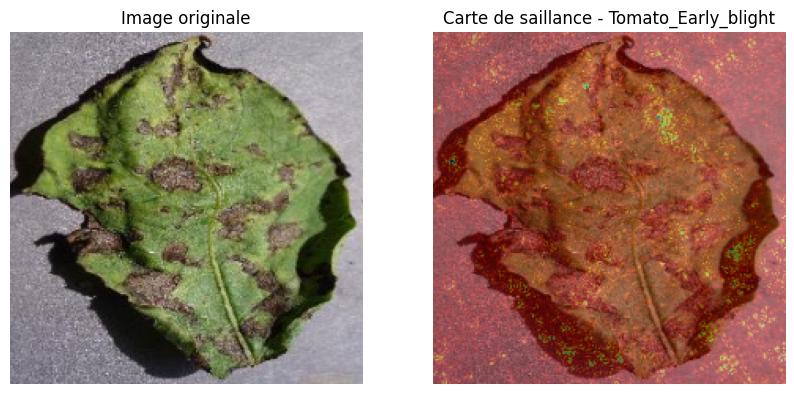

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. S'assurer que l'image est au bon format (batch, 224, 224, 3)
#    img_array est déjà prétraité avec preprocess_input
img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

# 2. Calculer les gradients par rapport à l'image
with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    predictions = model(img_tensor)
    pred_class = tf.argmax(predictions[0])
    loss = predictions[0, pred_class]

gradients = tape.gradient(loss, img_tensor)

# 3. Carte de saillance : moyenne des valeurs absolues sur les canaux
saliency = tf.reduce_mean(tf.abs(gradients), axis=-1)[0]

# 4. Normalisation entre 0 et 1
saliency = (saliency - tf.reduce_min(saliency)) / (tf.reduce_max(saliency) - tf.reduce_min(saliency) + 1e-10)
saliency = saliency.numpy()

print("✅ Carte de saillance générée, shape :", saliency.shape)

# 5. Visualisation
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
original_img = cv2.resize(original_img, (224, 224))

saliency_resized = cv2.resize(saliency, (224, 224))
heatmap = cv2.applyColorMap(np.uint8(255 * saliency_resized), cv2.COLORMAP_JET)
superimposed = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)
saliency_smooth = cv2.GaussianBlur(saliency, (5,5), 0)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("Image originale")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(superimposed)
plt.title(f"Carte de saillance - {class_names[pred_class]}")
plt.axis('off')
plt.show()

In [22]:
# Sauvegarde avant plt.show() pour éviter une image vide
plt.savefig("saliency_map.png", bbox_inches='tight', dpi=300)
print("✅ Carte de saillance sauvegardée sous 'saliency_map.png'")

✅ Carte de saillance sauvegardée sous 'saliency_map.png'


<Figure size 640x480 with 0 Axes>